In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np

# Optional interactive viewer
try:
    import napari
    HAVE_NAPARI = True
except ImportError:
    HAVE_NAPARI = False

output_npz_path = '../data/results_multiGPU/dem_all_20170906_12_00_12.npz'
original_npz_path = "../data/np32/20170906_12_00_12.npz"

# Optional: select frame and temperature index for visualization
frame_idx = 0
temp_idx = 0

In [16]:
# Load outputs and reshape to (H, W, T) if needed
with np.load(output_npz_path) as data:
    dem = data['dem_all']

print(f"Loaded DEM raw shape: {dem.shape}")  

Loaded DEM raw shape: (16777216, 10)


In [17]:

# If stored as (N, T) where N = H*W, reshape to (H, W, T)
if dem.ndim == 2:
    N, T = dem.shape
    side = int(np.sqrt(N))
    if side * side != N:
        raise ValueError(f"Cannot reshape first dimension {N} into a square image")
    dem = dem.reshape(side, side, T)
    print(f"Reshaped DEM to (H, W, T): {dem.shape}")
elif dem.ndim == 3:
    H, W, T = dem.shape
    print(f"DEM already has (H, W, T): {H}x{W}x{T}")
    T = dem.shape[2]
else:
    raise ValueError(f"Unexpected DEM ndim={dem.ndim}")

# Ensure temp_idx is valid
try:
    temp_idx
except NameError:
    temp_idx = 0
if not (0 <= temp_idx < T):
    print(f"temp_idx {temp_idx} out of range [0, {T-1}], resetting to 0")
    temp_idx = 0

Reshaped DEM to (H, W, T): (4096, 4096, 10)


DEM: min=-60560843321142296489263034959145770577850094031359473505835961768952299394925854720.000, max=225275972126203548721319085853966232791890736012260576898722053583895148806660947968.000, mean=31344479385482003331717426515976435166559500656794337161116647424.000


C:\Users\lukas\AppData\Local\Temp\ipykernel_20512\2338724205.py:14: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(dem[:, :, temp_idx]), cmap='viridis')
C:\Users\lukas\AppData\Local\Temp\ipykernel_20512\2338724205.py:14: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(dem[:, :, temp_idx]), cmap='viridis')


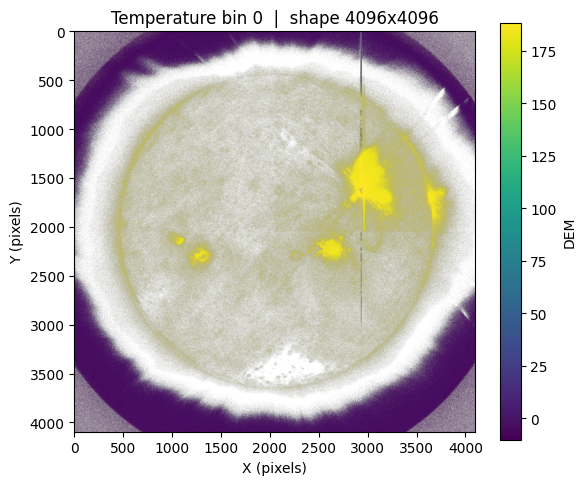

C:\Users\lukas\AppData\Local\Temp\ipykernel_20512\2338724205.py:26: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(summed), cmap='magma')
C:\Users\lukas\AppData\Local\Temp\ipykernel_20512\2338724205.py:26: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(summed), cmap='magma')


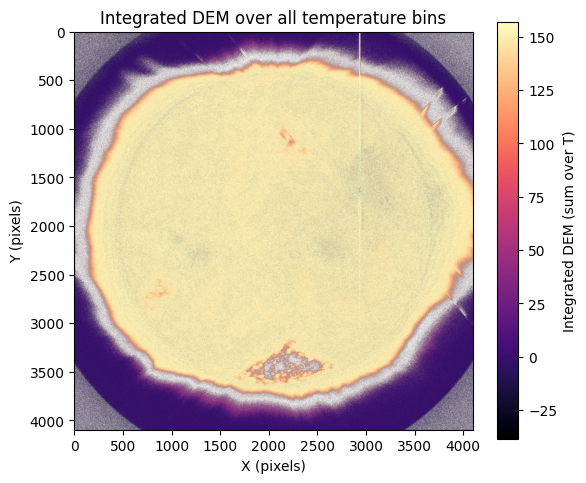

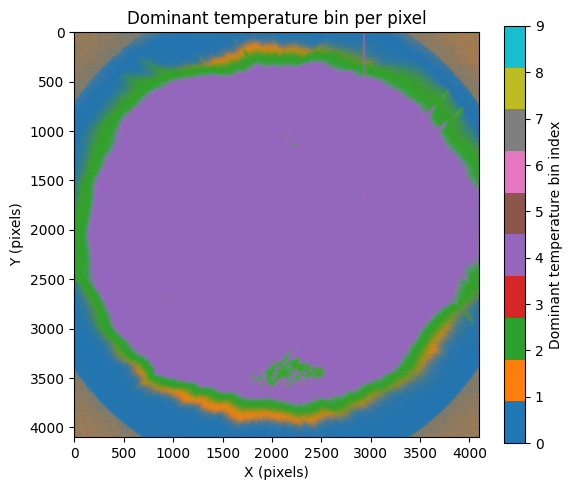

In [ ]:
# ------------------------------
# Basic statistics
print(f"DEM: min={dem.min():.3f}, max={dem.max():.3f}, mean={dem.mean():.3f}")

# Convenience vars
H, W, T = dem.shape

# show original


# ------------------------------
# Plot single temperature bin as an image
plt.figure(figsize=(6,5))
plt.imshow(np.log(dem[:, :, temp_idx]), cmap='viridis')
plt.colorbar(label='DEM')
plt.title(f'Temperature bin {temp_idx}  |  shape {H}x{W}')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.tight_layout()
plt.show()

# ------------------------------
# Sum across temperature bins (integrated DEM)
summed = dem.sum(axis=2)
plt.figure(figsize=(6,5))
plt.imshow(np.log(summed), cmap='magma')
plt.colorbar(label='Integrated DEM (sum over T)')
plt.title('Integrated DEM over all temperature bins')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.tight_layout()
plt.show()

# ------------------------------
# Dominant temperature bin per pixel
# argmax over T gives the index of the temperature bin with highest DEM at each pixel
dominant_bin = np.argmax(dem, axis=2)
plt.figure(figsize=(6,5))
plt.imshow(dominant_bin, cmap='tab10')
plt.colorbar(label='Dominant temperature bin index')
plt.title('Dominant temperature bin per pixel')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.tight_layout()
plt.show()